# Part 01: Nyquist frequency and rate
It is said that birds may sing with a frequency up to 8 kHz. What is the Nyquist frequency and the Nyquist rate for sampling such a bird song.

**Nyquist Sampling Rate** = double the maximum frequency => 16kHz

If we assume that we sample with 16kHz, then the Nyquist frequency (maximum frequency we can capture) would be 8kHz.

---
# Part 02: Data of digitalized sounds
**a)** Given the results of part 01, calculate the amount of data generated for a 1 minute recording of a birds song. The sound shall be recorded mono (1 channel) with 1 Byte per sample.

**b)** If MP3 can achieve a compression rate of 75% and 30 minutes are saved in a MP3 file. How big is the file?

**Answers:**
*   **a)** 1Hz = 1 Sample Point per Second
    60s * 16.000 1/s * 1 Byte = 960.000 Byte = **0.96 MB**
*   **b)** 30 * 60s * 16.000 1/s * 1 Byte * 0.75 = **21.6 MB**

---
# Part 03: EDA on Speech Commands
Here we apply the step-by-step feature extraction concepts to our actual **Speech Commands dataset**. 
We will load a 1-second 16kHz recording (e.g., the word "yes") and visualize its journey from a raw waveform to Mel-Frequency Cepstral Coefficients (MFCCs).

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io.wavfile
from scipy.fftpack import dct
from IPython.display import display, Audio

def plot_time_domain(signal, sample_rate, title="Signal in the Time Domain"):
    """Recreates the time-domain signal plots (Blue line, dashed grid)."""
    time = np.linspace(0, len(signal) / sample_rate, num=len(signal))
    plt.figure(figsize=(12, 3))
    plt.plot(time, signal, color='blue', linewidth=1)
    plt.title(title, y=-0.25)
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.xlim(0, time[-1])
    plt.tight_layout()
    plt.show()

def plot_spectrogram(data, sample_rate, title="Spectrogram", is_mfcc=False):
    """Plots heatmaps for Filter Banks or MFCCs."""
    plt.figure(figsize=(12, 3))
    # Speech commands are ~1.0 second long
    extent =[0, 1.0, 0, (sample_rate / 2) / 1000 if not is_mfcc else data.shape[1]]
    
    plt.imshow(data.T, aspect='auto', origin='lower', cmap='jet', extent=extent)
    plt.title(title, y=-0.25)
    plt.xlabel('Time (s)')
    
    if is_mfcc:
        plt.ylabel('MFCC Coefficients')
    else:
        plt.ylabel('Frequency (kHz)')
        
    plt.tight_layout()
    plt.show()


### 1. Load Audio and Visualize Waveform
We load a standard 1-second file from the dataset and provide a player so you can hear the command.

Sample Rate: 16000 Hz
Signal Length: 16000 samples


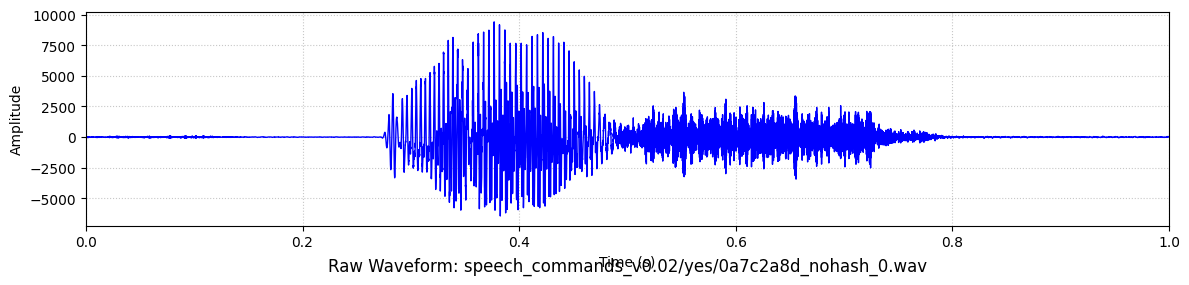

In [9]:
# Load a sample from the Speech Commands dataset
wav_file_path = 'speech_commands_v0.02/yes/0a7c2a8d_nohash_0.wav'

try:
    sample_rate, signal = scipy.io.wavfile.read(wav_file_path)
    # Speech commands are 1 second long max (16000 samples at 16kHz)
    signal = signal[0:int(1.0 * sample_rate)] 
    
    print(f"Sample Rate: {sample_rate} Hz")
    print(f"Signal Length: {len(signal)} samples")
    
    plot_time_domain(signal, sample_rate, f'Raw Waveform: {wav_file_path}')
    
    # Interactive Audio Player
    display(Audio(data=signal, rate=sample_rate))
    
except FileNotFoundError:
    print(f"❌ ERROR: Could not find '{wav_file_path}'. Please adjust the path.")


### 2. Pre-Emphasis
Applying a pre-emphasis filter to amplify high frequencies, which balances the frequency spectrum.

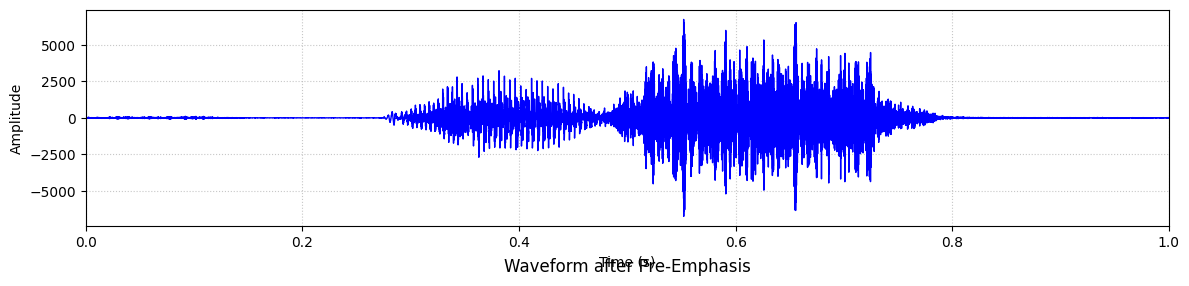

In [10]:
pre_emphasis = 0.97
emphasized_signal = np.append(signal[0], signal[1:] - pre_emphasis * signal[:-1])
plot_time_domain(emphasized_signal, sample_rate, 'Waveform after Pre-Emphasis')


### 3. Framing and Windowing (Hamming)
We split the signal into short frames (e.g., 25ms) and apply a Hamming window to prevent spectral leakage at the edges.

In [11]:
frame_size = 0.025   # 25 ms
frame_stride = 0.01  # 10 ms step

frame_length, frame_step = frame_size * sample_rate, frame_stride * sample_rate
signal_length = len(emphasized_signal)
frame_length = int(round(frame_length))
frame_step = int(round(frame_step))

num_frames = int(np.ceil(float(np.abs(signal_length - frame_length)) / frame_step))
pad_signal_length = num_frames * frame_step + frame_length
z = np.zeros((pad_signal_length - signal_length))
pad_signal = np.append(emphasized_signal, z)

indices = np.tile(np.arange(0, frame_length), (num_frames, 1)) + np.tile(np.arange(0, num_frames * frame_step, frame_step), (frame_length, 1)).T
frames = pad_signal[indices.astype(np.int32, copy=False)]

# Apply Hamming Window
frames *= np.hamming(frame_length)
print(f"Extracted {num_frames} frames of length {frame_length} samples.")


Extracted 98 frames of length 400 samples.


### 4. Fourier-Transform and Power Spectrum
We calculate the Fast Fourier Transform (FFT) for each frame to get the frequency magnitudes.

In [12]:
NFFT = 512
mag_frames = np.absolute(np.fft.rfft(frames, NFFT))  # Magnitude
pow_frames = ((1.0 / NFFT) * ((mag_frames) ** 2))    # Power Spectrum


### 5. Mel Filter Banks
Human hearing is logarithmic. We apply triangular filters mapped to the Mel scale to compress the frequency spectrum.

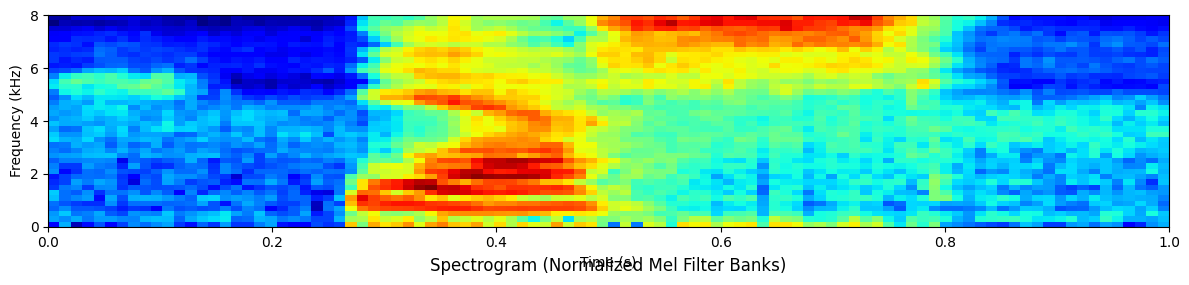

In [13]:
nfilt = 40
low_freq_mel = 0
high_freq_mel = (2595 * np.log10(1 + (sample_rate / 2) / 700)) 

mel_points = np.linspace(low_freq_mel, high_freq_mel, nfilt + 2) 
hz_points = (700 * (10**(mel_points / 2595) - 1)) 
bin = np.floor((NFFT + 1) * hz_points / sample_rate)

fbank = np.zeros((nfilt, int(np.floor(NFFT / 2 + 1))))
for m in range(1, nfilt + 1):
    f_m_minus = int(bin[m - 1])   # left
    f_m = int(bin[m])             # center
    f_m_plus = int(bin[m + 1])    # right
    
    for k in range(f_m_minus, f_m):
        fbank[m - 1, k] = (k - bin[m - 1]) / (bin[m] - bin[m - 1])
    for k in range(f_m, f_m_plus):
        fbank[m - 1, k] = (bin[m + 1] - k) / (bin[m + 1] - bin[m])

filter_banks = np.dot(pow_frames, fbank.T)
filter_banks = np.where(filter_banks == 0, np.finfo(float).eps, filter_banks) # Numerical Stability
filter_banks = 20 * np.log10(filter_banks) # Convert to dB

# Mean Normalization
filter_banks -= (np.mean(filter_banks, axis=0) + 1e-8)
plot_spectrogram(filter_banks, sample_rate, title="Spectrogram (Normalized Mel Filter Banks)")


### 6. Mel-Frequency Cepstral Coefficients (MFCCs)
Finally, we apply the Discrete Cosine Transform (DCT) to decorrelate the filter bank coefficients and yield a compressed representation. We typically keep only the first ~13 coefficients.

Final MFCC shape for one command: (98, 13)


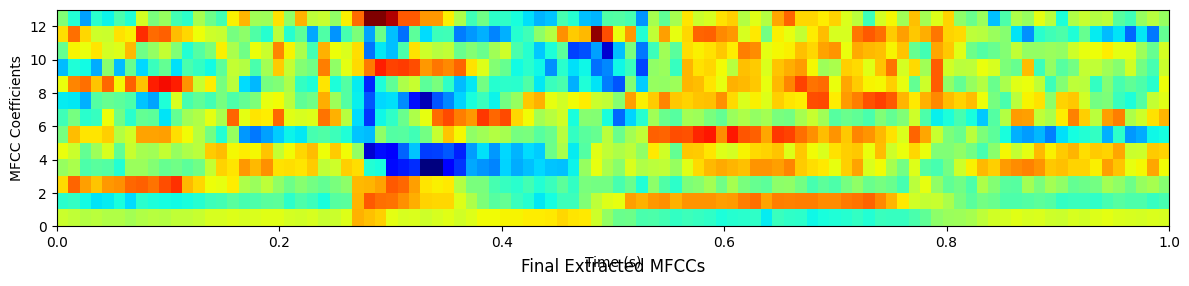

In [14]:
num_ceps = 13
mfcc = dct(filter_banks, type=2, axis=1, norm='ortho')[:, 1 : (num_ceps + 1)] # Keep 1-13

# Optional: Apply a sinusoidal liftering to the MFCCs to de-emphasize higher MFCCs
(nframes, ncoeff) = mfcc.shape
n = np.arange(ncoeff)
cep_lifter = 22
lift = 1 + (cep_lifter / 2) * np.sin(np.pi * n / cep_lifter)
mfcc *= lift 

# Mean Normalization for MFCCs
mfcc -= (np.mean(mfcc, axis=0) + 1e-8)

print(f"Final MFCC shape for one command: {mfcc.shape}")
plot_spectrogram(mfcc, sample_rate, title="Final Extracted MFCCs", is_mfcc=True)


### 7. Comparison: Intra-Class vs. Inter-Class
Now, let's use `librosa` to generate a side-by-side grid comparing Mel Spectrograms and MFCCs.
We will compare **two of the same class** (to see how similar words look visually) and **different classes** (to see how easily separable they might be for a Machine Learning model).

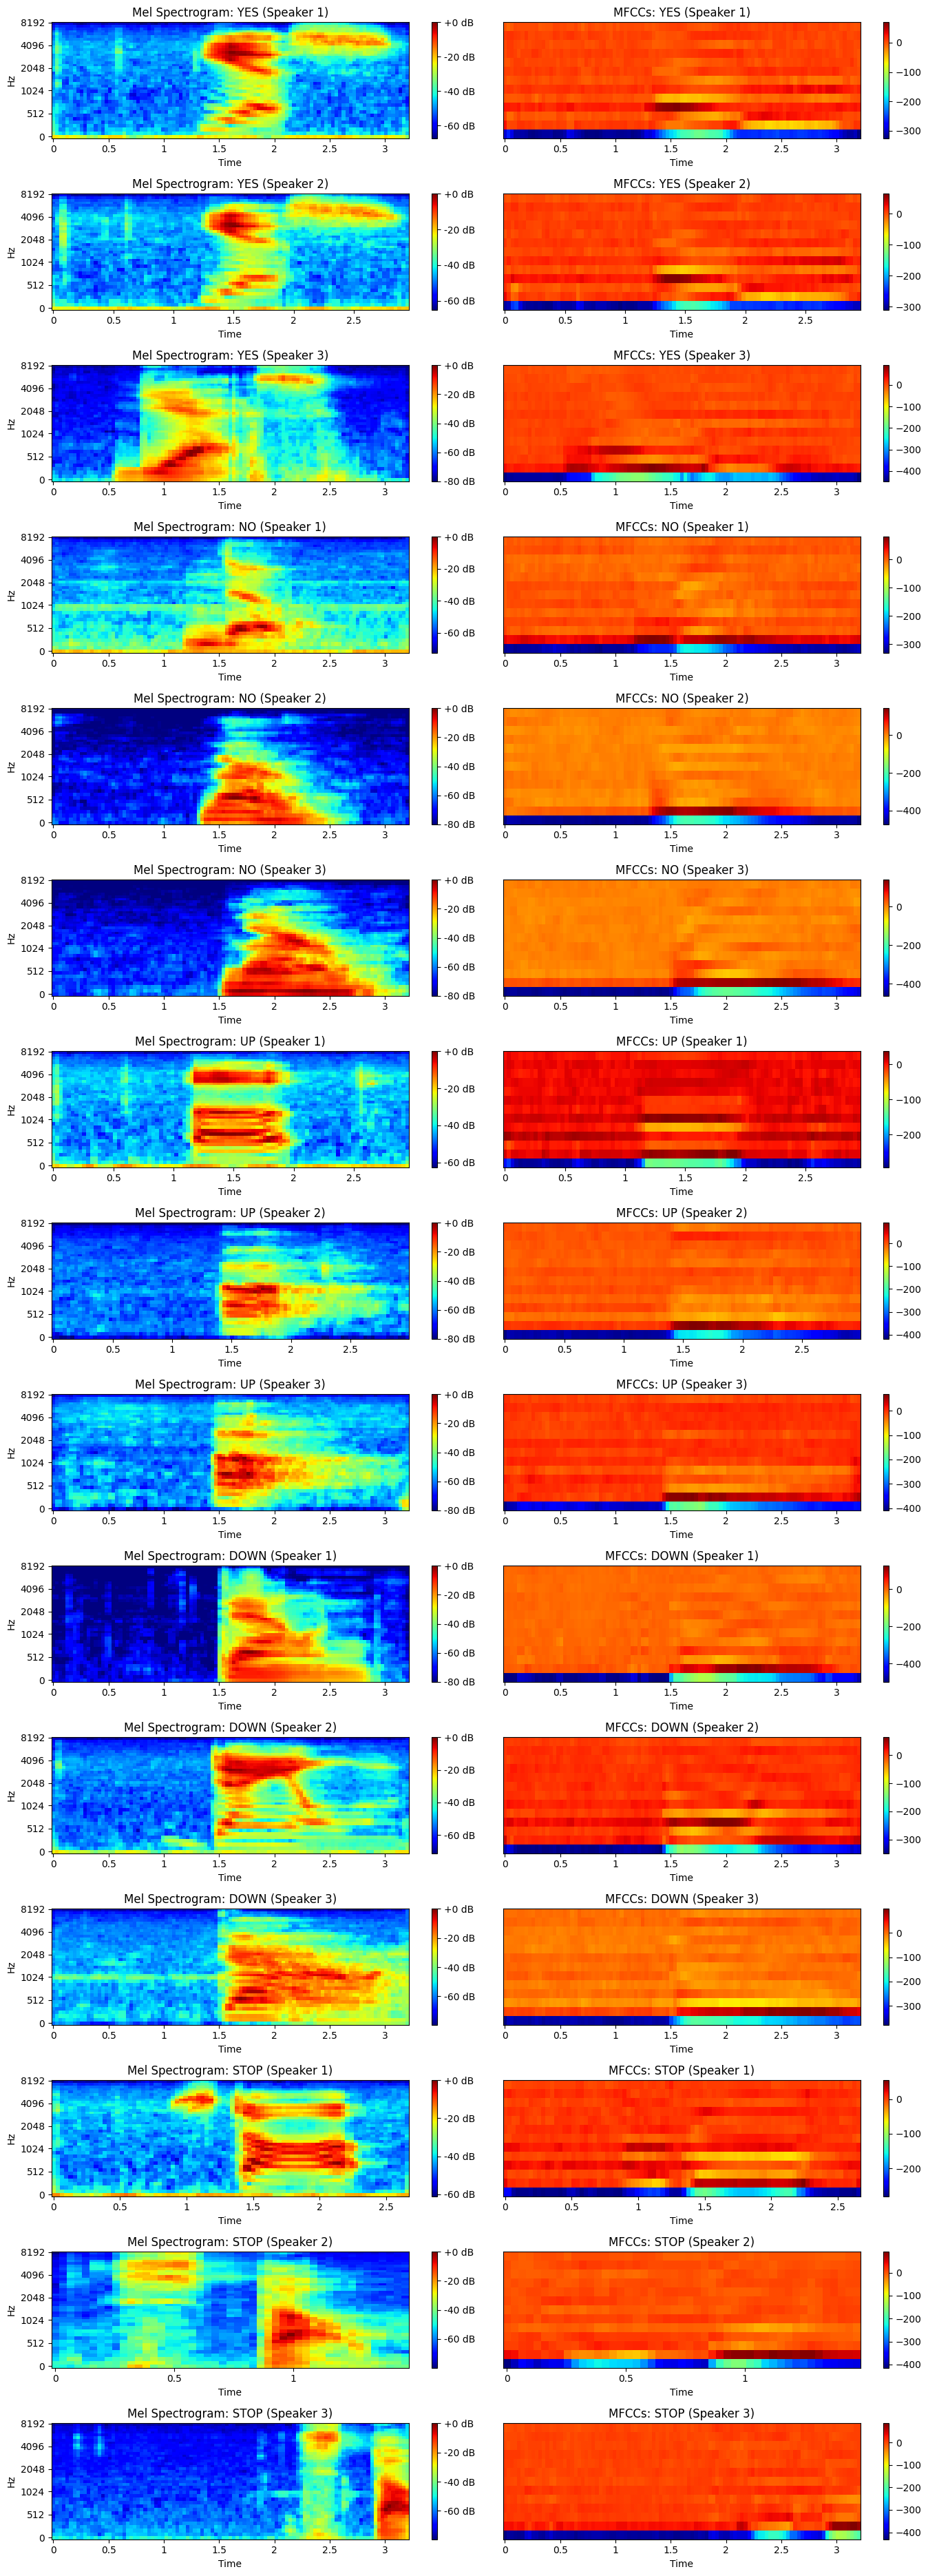

In [17]:
import os
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt

base_dir = 'speech_commands_v0.02'

# Define which classes to compare and how many examples per class
classes_to_compare =['yes', 'no', 'up', 'down', 'stop']
samples_per_class = 3

selected_paths = []
selected_labels =[]

# Dynamically gather the files
for c in classes_to_compare:
    class_dir = os.path.join(base_dir, c)
    if os.path.exists(class_dir):
        # Grab the first 'n' audio files for this class
        files = [f for f in os.listdir(class_dir) if f.endswith('.wav')][:samples_per_class]
        for i, f in enumerate(files):
            selected_paths.append(os.path.join(class_dir, f))
            selected_labels.append(f"{c.upper()} (Speaker {i+1})")

if not selected_paths:
    print(f"⚠️ Could not find audio files in {base_dir}. Make sure the dataset is extracted.")
else:
    num_rows = len(selected_paths)
    # Make the figure height dynamic based on the number of rows
    fig, axes = plt.subplots(num_rows, 2, figsize=(14, 2.5 * num_rows))
    
    for i, (path, label) in enumerate(zip(selected_paths, selected_labels)):
        y, sr = librosa.load(path, sr=16000)
        
        # Extract Mel Spectrogram
        S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=40, n_fft=512, hop_length=160)
        S_dB = librosa.power_to_db(S, ref=np.max)
        
        # Extract MFCC
        mfcc = librosa.feature.mfcc(S=S_dB, n_mfcc=13)
        
        # --- Plot Spectrogram ---
        ax_spec = axes[i, 0]
        img_spec = librosa.display.specshow(S_dB, sr=sr, x_axis='time', y_axis='mel', ax=ax_spec, cmap='jet')
        ax_spec.set_title(f'Mel Spectrogram: {label}')
        fig.colorbar(img_spec, ax=ax_spec, format='%+2.0f dB')
        
        # --- Plot MFCC ---
        ax_mfcc = axes[i, 1]
        img_mfcc = librosa.display.specshow(mfcc, sr=sr, x_axis='time', ax=ax_mfcc, cmap='jet')
        ax_mfcc.set_title(f'MFCCs: {label}')
        fig.colorbar(img_mfcc, ax=ax_mfcc)
        
    plt.tight_layout()
    plt.show()